# Tutorial 2: Deep Dive into the Core Physics

In the previous tutorial, we used convenience methods to generate a sea-level fingerprint in just a few lines of code. Now, we are going to peel back the layers. 

In this tutorial, we will explicitly define our Earth's physical parameters, use an analytical ice model to generate a pristine synthetic Earth, and compare the results of the **linear** Sea Level Equation (fixed shorelines) against the **non-linear** Sea Level Equation (migrating shorelines).

Let's start by importing our plotting libraries, `cartopy` for map projections, and `pyslfp`.

In [1]:
# import the libraries either locally or installing when on colab
import matplotlib.pyplot as plt

try:
    import pyslfp as sl
except ImportError: 
    %pip install pyslfp --quiet
    import pyslfp as sl

from cartopy import  crs as ccrs

### Customizing the Earth Model and Initial State

Instead of relying on the defaults, we can explicitly define our non-dimensionalization scheme using `EarthModelParameters`. This is particularly useful if you are working with synthetic data or specifically scaled tests.

We will also use the `AnalyticalIceModel`. Instead of loading a real-world empirical data (like ICE-7G), this model generates a perfectly smooth, mathematically idealized Earth with synthetic continents and ice caps. This is highly recommended for testing and debugging, as it prevents the numerical "ringing" (aliasing) that can occur when projecting sharp real-world coastlines onto lower-resolution spherical harmonics.

Let's set up our custom Earth, generate the initial ice and topography, and plot our synthetic world using a custom `ccrs.Miller()` projection. Notice how we use `initial_state.plot_coastline()` to dynamically draw the coastlines based on the actual physics (where the ocean meets the land) rather than a static map!

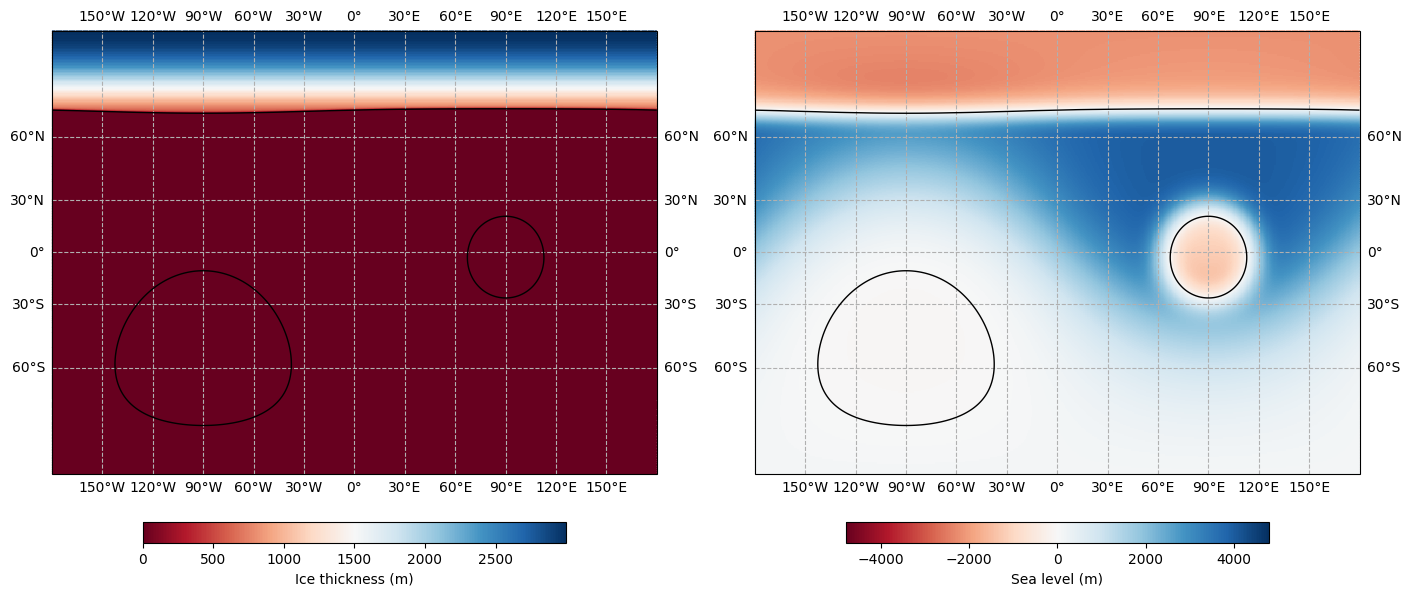

In [2]:
# Set up the parameters and non-dimensionalisation scheme
earth_parameters = sl.EarthModelParameters(
    length_scale=1000.0e3,  # One kilometre
    density_scale=1000.0e3,  # Approx density of water
    time_scale=3600.0,  # One hour
)

# Set the truncation degree for the calculations.
LMAX = 256

# Set up the earth model using default Love number file.
earth_model = sl.EarthModel(LMAX, parameters=earth_parameters)

# For the initial state, use the simple in-built analytic model.
ice_model = sl.ice.AnalyticalIceModel(length_scale=earth_parameters.length_scale)

# Visualise the ice thickness and the sea level
ice_thickness, sea_level = ice_model.get_ice_thickness_and_sea_level(0, LMAX)

# Set up the initial state -- the option to exclude the Caspian sea from the 
# ocean function is turned off as it doesn't apply here. 
initial_state = sl.EarthState(ice_thickness, sea_level, earth_model, exclude_caspian=False)

# Note that we need to provide a projection when creating figures
# as the plot functions is built on cartopy and not matplotlib directly. 
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.Miller()},
    layout="constrained",
)

# We turn off the default inclusion of coastlines for the Earth.
sl.plot(
    ice_thickness * earth_parameters.length_scale,
    ax=ax1,
    coasts=False,
    colorbar_kwargs={"label": "Ice thickness (m)"},
)

sl.plot(
    sea_level * earth_parameters.length_scale,
    ax=ax2,
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Sea level (m)"},
)

# But we can add in the custom coastline based on 
# the zero set of the function rho_w * SL - rho_i * I
initial_state.plot_coastline(ax1)
initial_state.plot_coastline(ax2)

plt.show()

### Constructing a Custom Ice Load

In the first tutorial, we used a built-in convenience method to melt the West Antarctic. But what if you want to test a completely custom scenario? 

Because `pyslfp` is built on top of `pyshtools`, all spatial data is stored as `SHGrid` objects. We can interact directly with the underlying NumPy arrays to create custom masks. 

Let's create a drastic scenario: melting 100% of the ice in the Western Hemisphere. We will generate a grid of zeros, create a boolean mask based on the longitudes, and apply it to our initial ice thickness.

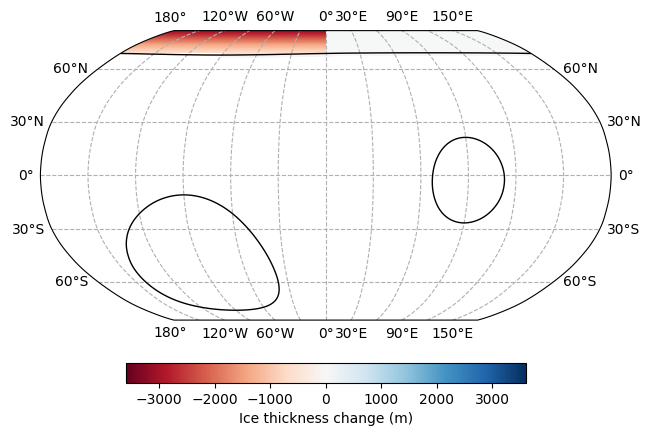

In [3]:
# 1. Initialize an empty grid compatible with our Earth model
ice_thickness_change = earth_model.zero_grid()

# 2. Create a spatial mask for the Western Hemisphere (longitudes > 180 or < 0)
lons = ice_thickness_change.lons()
west_mask = (lons > 180) | (lons < 0)

# Set the mask to -1 (representing 100% melt) in the west, leaving the east at 0
ice_thickness_change.data[:, west_mask] = -1.0

# 3. Multiply by the actual initial ice thickness to get the absolute change
ice_thickness_change *= ice_thickness 



# 4. Visualize the custom melt scenario
# When an axis is not provided, sl.plot() automatically generates a new 
# figure using the default Robinson projection.
ax, im = sl.plot(
    ice_thickness_change 
    * initial_state.ice_projection() 
    * earth_parameters.length_scale, 
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Ice thickness change (m)"}
)

# Overlay the initial coastline for context
initial_state.plot_coastline(ax)

plt.show()

### Solving the Sea Level Equation and Extracting All Fields

In Tutorial 1, we used the `LinearSeaLevelEquation.from_defaults()` shortcut. Here, we will explicitly initialize the solver using our custom `earth_model`. 

Before we can solve the equation, we need to convert our raw `ice_thickness_change` (which is just a spatial grid of heights) into a physical `direct_load`. The `initial_state` object handles this conversion, applying the correct density scaling and masking out areas over the ocean where there are ice shelves. 

Once we solve the equation, we will unpack all four of the outputs:
1. `slc`: Relative Sea Level Change
2. `disp`: Solid Earth Vertical Displacement
3. `potc`: Gravitational Potential Change
4. `avc`: Angular Velocity Change (Polar Wander - a single vector, not a spatial grid)

Let's solve it and use Matplotlib's `subplot_mosaic` to map the three spatial fields in a clean layout! *Note: We divide the potential change (`potc`) by gravity to convert it into a measurable "geoid anomaly" in meters.*

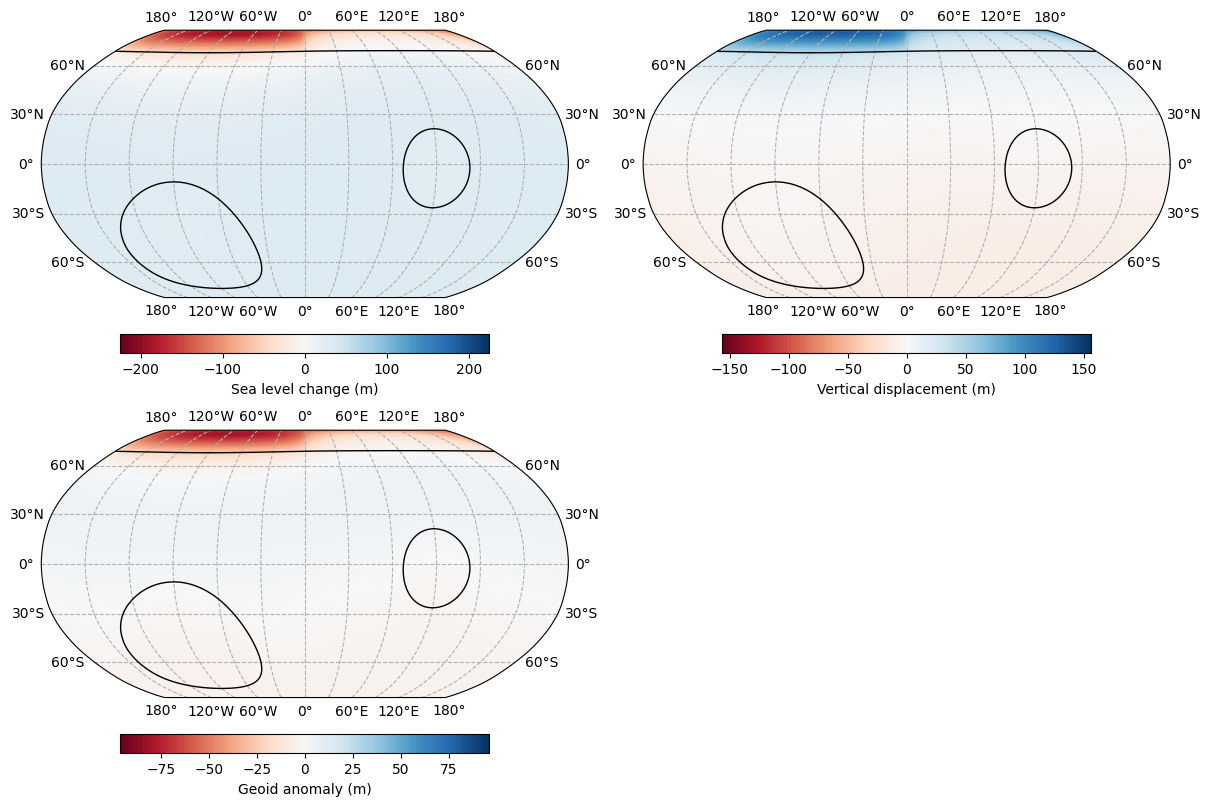

In [4]:
# Initialize the sea level solver with our custom Earth model
sle = sl.SeaLevelEquation(earth_model)

# Convert the ice thickness change into a physical mass load
direct_load = initial_state.direct_load_from_ice_thickness_change(ice_thickness_change)

# Solve the linearised sea level equation and store all outputs
slc, disp, potc, avc = sle.solve_sea_level_equation(initial_state, direct_load)

# 1. Define the layout with keys for our fields
layout = [
    ["slc", "disp"],
    ["potc", "."]  
]

# 2. Create the figure and a dictionary of axes using subplot_mosaic
fig, ax_dict = plt.subplot_mosaic(
    layout,
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    layout="constrained"
)

# --- Plot Sea Level Change (slc) ---
sl.plot(
    slc * earth_parameters.length_scale,
    ax=ax_dict["slc"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Sea level change (m)"}
)
initial_state.plot_coastline(ax_dict["slc"])

# --- Plot Vertical Displacement (disp) ---
sl.plot(
    disp * earth_parameters.length_scale,
    ax=ax_dict["disp"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Vertical displacement (m)"}
)
initial_state.plot_coastline(ax_dict["disp"])

# --- Plot Geoid Anomaly (derived from potc) ---
sl.plot(
    -1 * potc * earth_parameters.length_scale / earth_parameters.gravitational_acceleration,
    ax=ax_dict["potc"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Geoid anomaly (m)"} 
)
initial_state.plot_coastline(ax_dict["potc"])

plt.show()

### The Non-Linear Equation: Migrating Shorelines

In the real world, shorelines are not static. When a massive ice sheet melts, the localized sea-level drop and land uplift cause the ocean to retreat, exposing new land. Conversely, in the far field, rising waters can inundate coastal areas. 

To capture this, we use the non-linear Sea Level Equation. This solver iteratively updates the ocean function (the map of where water actually is) as the physics evolve. 

Notice that `solve_nonlinear_equation` takes the raw `ice_thickness_change` directly, and its first output is a completely **new Earth state** reflecting the updated coastline. Let's solve it and plot the results. Crucially, in the bottom right panel, we will plot the *difference* between the linear and non-linear sea-level change, overlaying both the old and new coastlines to see exactly where shoreline migration occurred!

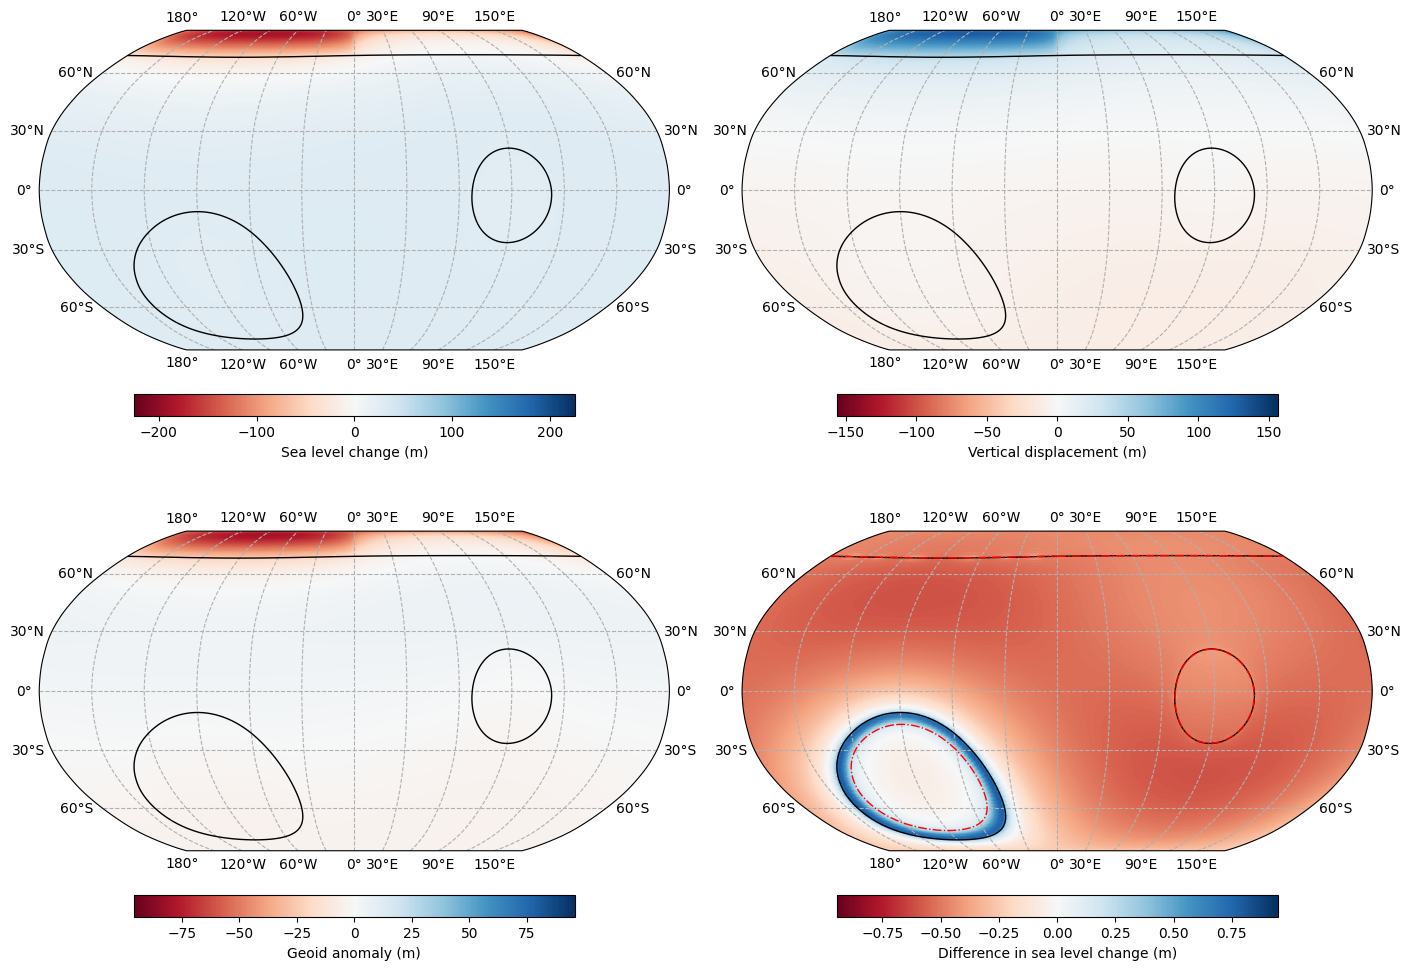

In [5]:
# The SeaLevelEquation class handles both linear and non-linear problems.
# We pass the solver the raw ice thickness change directly. 
# (It can also take changes to sediment thickness and ocean dynamic sea level).
new_state, slc_nonlin, disp, potc, avc = sle.solve_nonlinear_equation(
    initial_state, 
    ice_thickness_change=ice_thickness_change
)

# 1. Define the 2x2 layout, this time utilizing the bottom right for the difference
layout = [
    ["slc", "disp"],
    ["potc", "diff"]
]

# 2. Create the figure and the dictionary of axes
fig, ax_dict = plt.subplot_mosaic(
    layout,
    figsize=(14, 10),
    subplot_kw={"projection": ccrs.Robinson()},
    layout="constrained"
)

# --- Plot Non-Linear Sea Level Change (slc) ---
sl.plot(
    slc_nonlin * earth_parameters.length_scale,
    ax=ax_dict["slc"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Sea level change (m)"}
)
initial_state.plot_coastline(ax_dict["slc"])

# --- Plot Vertical Displacement (disp) ---
sl.plot(
    disp * earth_parameters.length_scale,
    ax=ax_dict["disp"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Vertical displacement (m)"}
)
initial_state.plot_coastline(ax_dict["disp"])

# --- Plot Geoid Anomaly (potc) ---
sl.plot(
    -1 * potc * earth_parameters.length_scale / earth_parameters.gravitational_acceleration,
    ax=ax_dict["potc"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Geoid anomaly (m)"} 
)
initial_state.plot_coastline(ax_dict["potc"])

# --- Plot the Difference (Linear vs Non-Linear) ---
sl.plot(
    (slc_nonlin - slc) * earth_parameters.length_scale, 
    ax=ax_dict["diff"],
    coasts=False,
    symmetric=True,
    colorbar_kwargs={"label": "Difference in sea level change (m)"}
)

# Plot the old coastline in black, and the new migrated coastline in red
initial_state.plot_coastline(ax_dict["diff"], linestyles="-")
new_state.plot_coastline(ax_dict["diff"], color="red", linestyles="-.")

plt.show()

### Conclusion

Excellent work! You have successfully stepped out of the high-level convenience wrappers and built a custom physical simulation from the ground up. 

By explicitly defining your Earth model, generating an analytical state to prevent numerical artifacts, and manually manipulating the underlying spherical function grids, you now have complete control over the physics engine. Furthermore, you can now see exactly why the non-linear solver is so important: shoreline migration causes distinct feedback loops in the sea-level footprint that the linear equation misses.